In [62]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from pathlib import Path

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Topic modelling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Network analysis
import networkx as nx
import community as community_louvain

print("All libraries imported successfully.")

All libraries imported successfully.


In [63]:
# Download required NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("NLTK resources downloaded.")

NLTK resources downloaded.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\himan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\himan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\himan\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [64]:
# Project paths
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"

DATA_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Data folder:", DATA_DIR.resolve())
print("Figures folder:", FIGURES_DIR.resolve())

Data folder: C:\Users\himan\Downloads\SMNA_Assignment2_AI_Job_Anxiety\data
Figures folder: C:\Users\himan\Downloads\SMNA_Assignment2_AI_Job_Anxiety\figures


In [65]:
real_path = DATA_DIR / "reddit_ai_jobs_public.csv"

df = pd.read_csv(real_path)

print("Real Reddit dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Real Reddit dataset loaded successfully.
Shape: (23525, 13)


,post_id,comment_id,subreddit,created_utc,author,parent_author,title,text,score,num_comments,url,keyword,parent_id
0,1t6f33z,NaN,cscareerquestions,1.778170e+09,throwaway09234023322,NaN,AI isn't going to take your job and here's why,AI isn't going to take your job and here's why...,96,158,https://www.reddit.com/r/cscareerquestions/com...,AI jobs,NaN
1,1t6f33z,okh0tv1,cscareerquestions,1.778171e+09,MD90__,throwaway09234023322,AI isn't going to take your job and here's why,Well I mean cheaper labor can use AI too so a ...,159,158,https://www.reddit.com/r/cscareerquestions/com...,AI jobs,t3_1t6f33z
2,1t6f33z,okh1luf,cscareerquestions,1.778171e+09,throwaway09234023322,MD90__,AI isn't going to take your job and here's why,"Tbh, while what you are saying makes logical s...",28,158,https://www.reddit.com/r/cscareerquestions/com...,AI jobs,t1_okh0tv1
3,1t6f33z,okh2hl1,cscareerquestions,1.778171e+09,MD90__,throwaway09234023322,AI isn't going to take your job and here's why,What about the folks coming out of college sin...,7,158,https://www.reddit.com/r/cscareerquestions/com...,AI jobs,t1_okh1luf
4,1t6f33z,okh33et,cscareerquestions,1.778171e+09,throwaway09234023322,MD90__,AI isn't going to take your job and here's why,"I think so, but I think it will take a bit of ...",10,158,https://www.reddit.com/r/cscareerquestions/com...,AI jobs,t1_okh2hl1


In [66]:
# Load real Reddit dataset
real_path = DATA_DIR / "reddit_ai_jobs_public.csv"

print("Looking for file here:")
print(real_path.resolve())

print("File exists:", real_path.exists())

df = pd.read_csv(real_path)

print("Real Reddit dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Looking for file here:
C:\Users\himan\Downloads\SMNA_Assignment2_AI_Job_Anxiety\data\reddit_ai_jobs_public.csv
File exists: True
Real Reddit dataset loaded successfully.
Shape: (23525, 13)


,post_id,comment_id,subreddit,created_utc,author,parent_author,title,text,score,num_comments,url,keyword,parent_id
0,1t6f33z,NaN,cscareerquestions,1.778170e+09,throwaway09234023322,NaN,AI isn't going to take your job and here's why,AI isn't going to take your job and here's why...,96,158,https://www.reddit.com/r/cscareerquestions/com...,AI jobs,NaN
1,1t6f33z,okh0tv1,cscareerquestions,1.778171e+09,MD90__,throwaway09234023322,AI isn't going to take your job and here's why,Well I mean cheaper labor can use AI too so a ...,159,158,https://www.reddit.com/r/cscareerquestions/com...,AI jobs,t3_1t6f33z
2,1t6f33z,okh1luf,cscareerquestions,1.778171e+09,throwaway09234023322,MD90__,AI isn't going to take your job and here's why,"Tbh, while what you are saying makes logical s...",28,158,https://www.reddit.com/r/cscareerquestions/com...,AI jobs,t1_okh0tv1
3,1t6f33z,okh2hl1,cscareerquestions,1.778171e+09,MD90__,throwaway09234023322,AI isn't going to take your job and here's why,What about the folks coming out of college sin...,7,158,https://www.reddit.com/r/cscareerquestions/com...,AI jobs,t1_okh1luf
4,1t6f33z,okh33et,cscareerquestions,1.778171e+09,throwaway09234023322,MD90__,AI isn't going to take your job and here's why,"I think so, but I think it will take a bit of ...",10,158,https://www.reddit.com/r/cscareerquestions/com...,AI jobs,t1_okh2hl1


## Dataset Overview

This sample dataset represents Reddit discussions about AI job replacement, automation, career anxiety, reskilling, and software engineering jobs. The dataset includes textual content for NLP analysis and reply relationships for network analysis. In the final project, this sample dataset will be replaced or extended with real Reddit data collected from selected subreddits.

## Text Cleaning and Preprocessing

Following the NLP pipeline from the lecture slides, the Reddit text is cleaned before analysis. The preprocessing step removes URLs, punctuation, numbers, extra spaces, and stopwords. The remaining words are then lemmatised so that different forms of the same word are treated more consistently.

In [67]:
# Text preprocessing setup
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Add custom stopwords for this project
custom_stopwords = {
    "ai", "chatgpt", "reddit", "would", "could", "also", "like", "get", "one",
    "think", "really", "much", "many", "people", "job", "jobs"
}

stop_words = stop_words.union(custom_stopwords)

def clean_text(text):
    """
    Clean Reddit text for NLP analysis.
    """
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,AI isn't going to take your job and here's why...,going take software engineer going used take e...
1,Well I mean cheaper labor can use AI too so a ...,well mean cheaper labor use global market tech...
2,"Tbh, while what you are saying makes logical s...",tbh saying make logical sense personally witne...
3,What about the folks coming out of college sin...,folk coming college since entry level dead chance
4,"I think so, but I think it will take a bit of ...",take bit time realize silver bullet magically ...


In [68]:
# Check cleaned text examples
for i in range(5):
    print("Original:")
    print(df.loc[i, "text"])
    print("\nCleaned:")
    print(df.loc[i, "clean_text"])
    print("-" * 80)

Original:
AI isn't going to take your job and here's why Software engineers are going to be used to take everyone else's jobs. We have been doing it for decades. We destroyed records, VHS, CDs, DVDs, movie rentals etc. We're destroying movie theaters. We destroyed everything related to the old photo industry. We decimated travel agents with online platforms. We destroyed cab drivers and now we are trying to destroy uber drivers with self driving cars. Newspapers and magazines are basically dead. We obliterated retailers and created platforms to assist with purchasing cheap goods from China.  People in tech should stop whining about AI taking our jobs because it isn't. Instead, we are going to be the ones using AI to take over the rest of the industries that we haven't already destroyed. I look forward to the future.  TLDR: all white collar jobs are fuck except for tech people.

Cleaned:
going take software engineer going used take everyone else decade destroyed record vhs cd dvd movie 

## Unigram and Bigram Analysis

Unigram analysis identifies frequent individual words, while bigram analysis identifies frequent two-word phrases. This is useful because individual words show general themes, while bigrams preserve short phrase structure such as "entry level", "software engineering", and "career anxiety".

In [69]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Combine all cleaned text
all_clean_text = " ".join(df["clean_text"].dropna())

# Unigram frequency
unigram_counts = Counter(all_clean_text.split())
top_unigrams = pd.DataFrame(
    unigram_counts.most_common(20),
    columns=["word", "count"]
)

top_unigrams

,word,count
0,company,4406
1,work,4380
2,year,3371
3,time,3141
4,thing,2808
5,make,2750
6,even,2731
7,need,2532
8,know,2332
9,good,2258


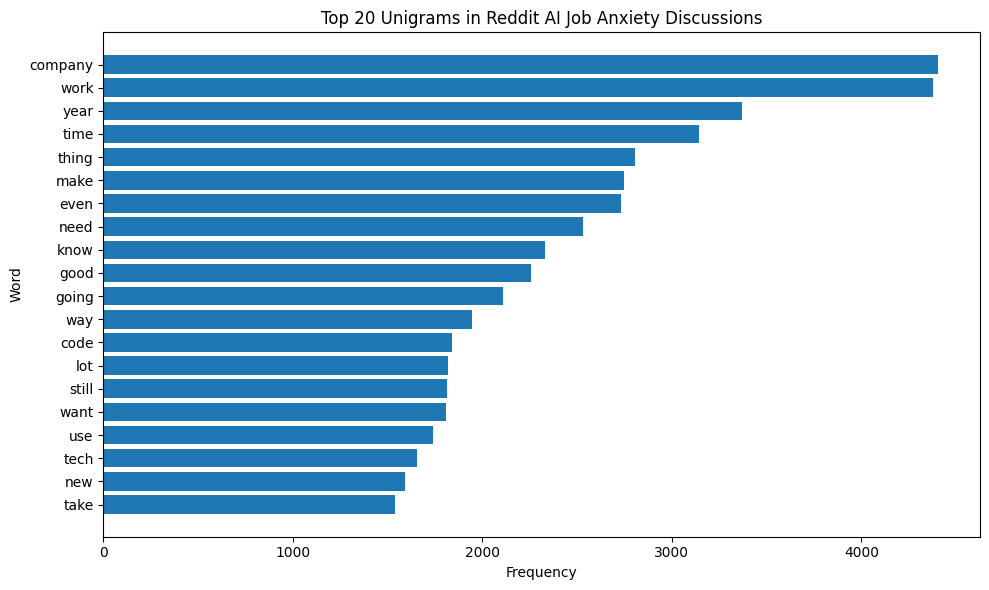

Saved figure to: ..\figures\top_20_unigrams.png


In [70]:
# Plot top unigrams
plt.figure(figsize=(10, 6))
plt.barh(top_unigrams["word"][::-1], top_unigrams["count"][::-1])
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 20 Unigrams in Reddit AI Job Anxiety Discussions")
plt.tight_layout()

unigram_fig_path = FIGURES_DIR / "top_20_unigrams.png"
plt.savefig(unigram_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", unigram_fig_path)

In [71]:
# Bigram frequency
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), min_df=1)
bigram_matrix = bigram_vectorizer.fit_transform(df["clean_text"])

bigram_counts = bigram_matrix.sum(axis=0).A1
bigram_terms = bigram_vectorizer.get_feature_names_out()

top_bigrams = pd.DataFrame({
    "bigram": bigram_terms,
    "count": bigram_counts
}).sort_values(by="count", ascending=False).head(20)

top_bigrams

,bigram,count
94863,entry level,460
344075,year ago,373
278121,software engineer,347
164357,last year,233
278122,software engineering,224
176335,long term,216
301103,tech company,201
334728,white collar,192
30407,big tech,185
182595,make sense,177


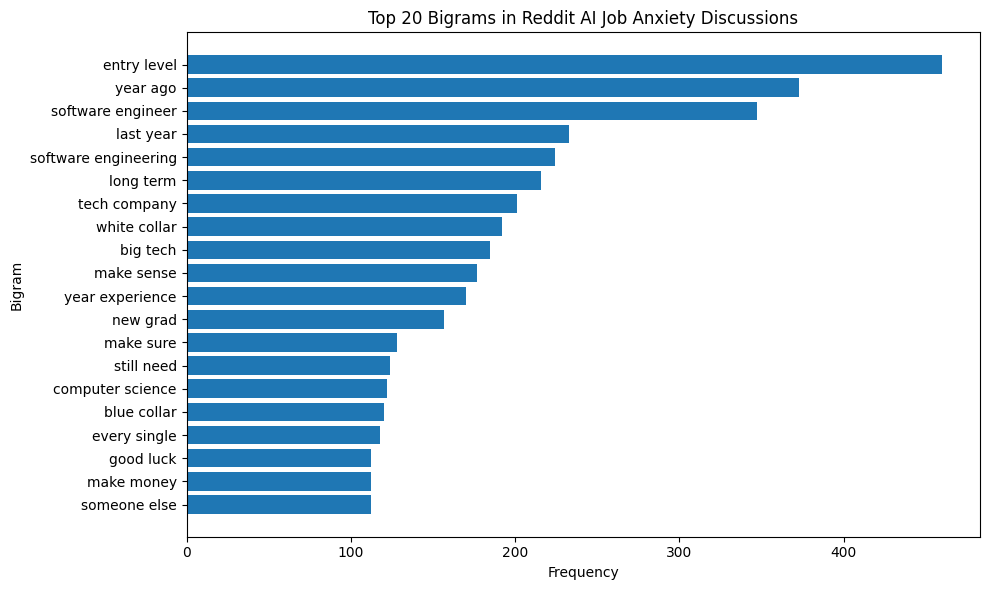

Saved figure to: ..\figures\top_20_bigrams.png


In [72]:
# Plot top bigrams
plt.figure(figsize=(10, 6))
plt.barh(top_bigrams["bigram"][::-1], top_bigrams["count"][::-1])
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Top 20 Bigrams in Reddit AI Job Anxiety Discussions")
plt.tight_layout()

bigram_fig_path = FIGURES_DIR / "top_20_bigrams.png"
plt.savefig(bigram_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", bigram_fig_path)

## Sentiment Analysis

VADER sentiment analysis is used to classify each Reddit post or comment as positive, neutral, or negative. The compound score is used because it summarises the overall sentiment polarity of the text. A compound score greater than or equal to 0.05 is classified as positive, a score less than or equal to -0.05 is classified as negative, and scores between these thresholds are classified as neutral.

In [73]:
# VADER sentiment analysis
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
    return analyzer.polarity_scores(str(text))

def classify_sentiment(compound_score):
    if compound_score >= 0.05:
        return "Positive"
    elif compound_score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis to original text, not cleaned text
df["sentiment_scores"] = df["text"].apply(get_sentiment_scores)
df["compound"] = df["sentiment_scores"].apply(lambda x: x["compound"])
df["sentiment"] = df["compound"].apply(classify_sentiment)

df[["subreddit", "text", "compound", "sentiment"]].head()

,subreddit,text,compound,sentiment
0,cscareerquestions,AI isn't going to take your job and here's why...,-0.9800,Negative
1,cscareerquestions,Well I mean cheaper labor can use AI too so a ...,0.5106,Positive
2,cscareerquestions,"Tbh, while what you are saying makes logical s...",-0.3182,Negative
3,cscareerquestions,What about the folks coming out of college sin...,-0.5661,Negative
4,cscareerquestions,"I think so, but I think it will take a bit of ...",0.0000,Neutral


In [74]:
# Sentiment distribution
sentiment_counts = df["sentiment"].value_counts().reset_index()
sentiment_counts.columns = ["sentiment", "count"]

sentiment_counts

,sentiment,count
0,Positive,11741
1,Negative,7144
2,Neutral,4640


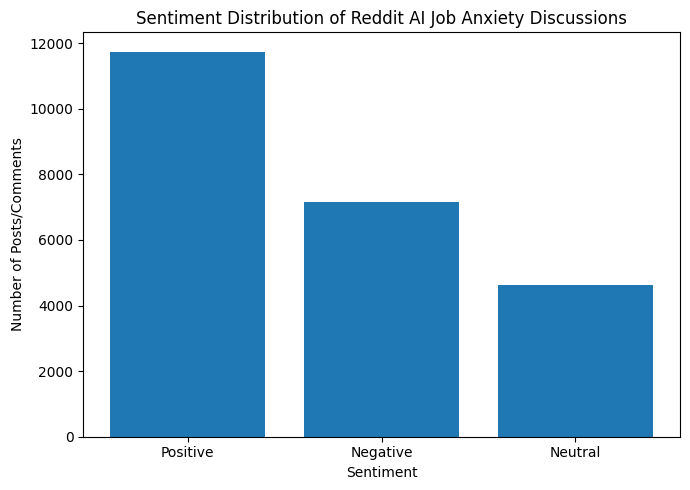

Saved figure to: ..\figures\sentiment_distribution.png


In [75]:
# Plot sentiment distribution
plt.figure(figsize=(7, 5))
plt.bar(sentiment_counts["sentiment"], sentiment_counts["count"])
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts/Comments")
plt.title("Sentiment Distribution of Reddit AI Job Anxiety Discussions")
plt.tight_layout()

sentiment_fig_path = FIGURES_DIR / "sentiment_distribution.png"
plt.savefig(sentiment_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", sentiment_fig_path)

In [76]:
# Sentiment by subreddit
sentiment_by_subreddit = (
    df.groupby(["subreddit", "sentiment"])
    .size()
    .reset_index(name="count")
)

sentiment_by_subreddit

,subreddit,sentiment,count
0,careerguidance,Negative,724
1,careerguidance,Neutral,532
2,careerguidance,Positive,1603
3,cscareerquestions,Negative,1861
4,cscareerquestions,Neutral,1212
5,cscareerquestions,Positive,3384
6,jobs,Negative,1571
7,jobs,Neutral,1009
8,jobs,Positive,2262
9,learnprogramming,Negative,511


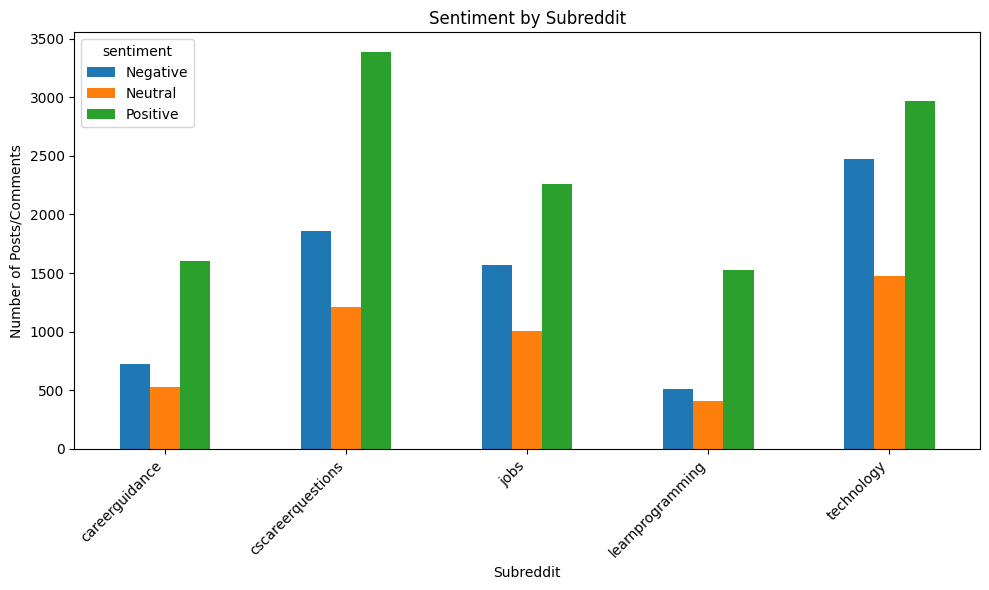

Saved figure to: ..\figures\sentiment_by_subreddit.png


In [77]:
# Plot sentiment by subreddit
sentiment_pivot = sentiment_by_subreddit.pivot(
    index="subreddit",
    columns="sentiment",
    values="count"
).fillna(0)

sentiment_pivot.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Subreddit")
plt.ylabel("Number of Posts/Comments")
plt.title("Sentiment by Subreddit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

sentiment_subreddit_fig_path = FIGURES_DIR / "sentiment_by_subreddit.png"
plt.savefig(sentiment_subreddit_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", sentiment_subreddit_fig_path)

### Initial Sentiment Interpretation

The sentiment analysis provides an initial indication of how Reddit users discuss AI job replacement and career anxiety. Positive comments often frame AI as a tool for productivity or reskilling, while negative comments tend to focus on job insecurity, layoffs, and entry-level career concerns. Neutral comments usually discuss AI adoption or career change in a more factual way. In the final report, these results will be interpreted together with topic modelling and network analysis.

## LDA Topic Modelling

Latent Dirichlet Allocation (LDA) is used to identify hidden themes in Reddit discussions. LDA assumes that each document is a mixture of topics and each topic is a distribution of words. In this project, each Reddit post or comment is treated as a document, and the model is used to discover repeated themes such as job insecurity, reskilling, software engineering careers, automation, and AI-related productivity.

In [78]:
# Prepare documents for LDA
documents = df["clean_text"].fillna("").tolist()

# Remove empty documents
documents = [doc for doc in documents if doc.strip() != ""]

print("Number of documents for topic modelling:", len(documents))

Number of documents for topic modelling: 23380


In [79]:
# Vectorise text for LDA
vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=1,
    max_features=1000
)

dtm = vectorizer.fit_transform(documents)

print("Document-term matrix shape:", dtm.shape)

Document-term matrix shape: (23380, 1000)


In [80]:
# Train LDA model
num_topics = 3

lda_model = LatentDirichletAllocation(
    n_components=num_topics,
    random_state=42,
    learning_method="batch"
)

lda_model.fit(dtm)

print("LDA model trained successfully.")

LDA model trained successfully.


In [81]:
# Display top words for each topic
feature_names = vectorizer.get_feature_names_out()

def display_topics(model, feature_names, num_top_words=10):
    topic_rows = []
    
    for topic_idx, topic in enumerate(model.components_):
        top_word_indices = topic.argsort()[:-num_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_word_indices]
        
        topic_rows.append({
            "topic": f"Topic {topic_idx + 1}",
            "top_words": ", ".join(top_words)
        })
    
    return pd.DataFrame(topic_rows)

topic_table = display_topics(lda_model, feature_names, num_top_words=10)
topic_table

,topic,top_words
0,Topic 1,"code, use, software, engineer, work, thing, ne..."
1,Topic 2,"company, year, work, tech, money, going, make,..."
2,Topic 3,"time, work, know, thing, even, something, good..."


In [82]:
# Assign dominant topic to each document
topic_distribution = lda_model.transform(dtm)

dominant_topics = topic_distribution.argmax(axis=1) + 1

# Assign back to dataframe
df_non_empty = df[df["clean_text"].str.strip() != ""].copy()
df_non_empty["dominant_topic"] = dominant_topics

df_non_empty[["subreddit", "text", "clean_text", "dominant_topic"]].head()

,subreddit,text,clean_text,dominant_topic
0,cscareerquestions,AI isn't going to take your job and here's why...,going take software engineer going used take e...,2
1,cscareerquestions,Well I mean cheaper labor can use AI too so a ...,well mean cheaper labor use global market tech...,2
2,cscareerquestions,"Tbh, while what you are saying makes logical s...",tbh saying make logical sense personally witne...,1
3,cscareerquestions,What about the folks coming out of college sin...,folk coming college since entry level dead chance,2
4,cscareerquestions,"I think so, but I think it will take a bit of ...",take bit time realize silver bullet magically ...,1


In [83]:
# Count documents by dominant topic
topic_counts = (
    df_non_empty["dominant_topic"]
    .value_counts()
    .sort_index()
    .reset_index()
)

topic_counts.columns = ["topic", "count"]
topic_counts

,topic,count
0,1,5936
1,2,9809
2,3,7635


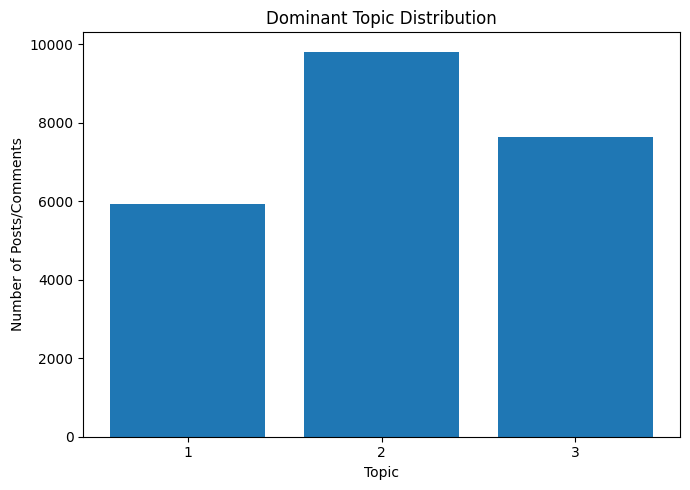

Saved figure to: ..\figures\topic_distribution.png


In [84]:
# Plot topic distribution
plt.figure(figsize=(7, 5))
plt.bar(topic_counts["topic"].astype(str), topic_counts["count"])
plt.xlabel("Topic")
plt.ylabel("Number of Posts/Comments")
plt.title("Dominant Topic Distribution")
plt.tight_layout()

topic_fig_path = FIGURES_DIR / "topic_distribution.png"
plt.savefig(topic_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", topic_fig_path)

In [85]:
# Manual topic labels based on top words
topic_labels = {
    1: "Career anxiety and entry-level concerns",
    2: "Reskilling and future work adaptation",
    3: "AI adoption, automation, and productivity"
}

df_non_empty["topic_label"] = df_non_empty["dominant_topic"].map(topic_labels)

df_non_empty[["subreddit", "dominant_topic", "topic_label", "text"]].head(10)

,subreddit,dominant_topic,topic_label,text
0,cscareerquestions,2,Reskilling and future work adaptation,AI isn't going to take your job and here's why...
1,cscareerquestions,2,Reskilling and future work adaptation,Well I mean cheaper labor can use AI too so a ...
2,cscareerquestions,1,Career anxiety and entry-level concerns,"Tbh, while what you are saying makes logical s..."
3,cscareerquestions,2,Reskilling and future work adaptation,What about the folks coming out of college sin...
4,cscareerquestions,1,Career anxiety and entry-level concerns,"I think so, but I think it will take a bit of ..."
5,cscareerquestions,3,"AI adoption, automation, and productivity",Sadly people like me already in their 30s it m...
6,cscareerquestions,1,Career anxiety and entry-level concerns,Good luck convincing non-technical C-suite clo...
7,cscareerquestions,2,Reskilling and future work adaptation,It is the opposite. Now is the time to know a ...
8,cscareerquestions,2,Reskilling and future work adaptation,Except the US economy is basically held up by ...
9,cscareerquestions,2,Reskilling and future work adaptation,"The US stock market\* But, if these companies..."


### Initial Topic Modelling Interpretation

The LDA topic model provides an initial view of the main themes in the Reddit discussion. The topic labels are manually assigned by interpreting the highest-weighted words in each topic. This step is important because LDA produces word groups, but the researcher must interpret what those word groups mean in relation to the research questions. In the final report, the topic model will be evaluated using both interpretability and relevance to the project aim.

## Reddit Reply Network Analysis

A directed weighted reply network is constructed from Reddit comment relationships. Each node represents a Reddit user. A directed edge from User A to User B means that User A replied to User B. The graph is directed because reply direction matters, and weighted because repeated replies between the same pair of users indicate stronger interaction. Network measures are used to identify active users, users who receive attention, and users who bridge different discussion groups.

In [86]:
# Build directed weighted Reddit reply network

G = nx.DiGraph()

# Add nodes for all authors
for author in df["author"].dropna().unique():
    G.add_node(author)

# Add directed edges: author replies to parent_author
for _, row in df.iterrows():
    author = row["author"]
    parent_author = row["parent_author"]
    
    if pd.notna(author) and pd.notna(parent_author) and parent_author != "":
        if G.has_edge(author, parent_author):
            G[author][parent_author]["weight"] += 1
        else:
            G.add_edge(author, parent_author, weight=1)

print("Network created successfully.")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Network created successfully.
Number of nodes: 14759
Number of edges: 21584


In [87]:
# Network summary statistics

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

# Convert to undirected for some measures
G_undirected = G.to_undirected()

if num_nodes > 0:
    avg_degree = sum(dict(G.degree()).values()) / num_nodes
else:
    avg_degree = 0

print("Network Summary")
print("----------------")
print("Nodes:", num_nodes)
print("Edges:", num_edges)
print("Density:", round(density, 4))
print("Average degree:", round(avg_degree, 2))
print("Is directed:", G.is_directed())

Network Summary
----------------
Nodes: 14759
Edges: 21584
Density: 0.0001
Average degree: 2.92
Is directed: True


In [88]:
# Fast centrality measures for large Reddit reply network

in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
weighted_in_degree = dict(G.in_degree(weight="weight"))
weighted_out_degree = dict(G.out_degree(weight="weight"))

# PageRank is okay on larger graphs
pagerank = nx.pagerank(G, weight="weight", max_iter=100)

# Exact betweenness is too slow for large networks, so use approximate betweenness
sample_size = min(300, G.number_of_nodes())

betweenness = nx.betweenness_centrality(
    G.to_undirected(),
    k=sample_size,
    weight="weight",
    normalized=True,
    seed=42
)

centrality_df = pd.DataFrame({
    "user": list(G.nodes()),
    "in_degree": [in_degree.get(node, 0) for node in G.nodes()],
    "out_degree": [out_degree.get(node, 0) for node in G.nodes()],
    "weighted_in_degree": [weighted_in_degree.get(node, 0) for node in G.nodes()],
    "weighted_out_degree": [weighted_out_degree.get(node, 0) for node in G.nodes()],
    "pagerank": [pagerank.get(node, 0) for node in G.nodes()],
    "approx_betweenness": [betweenness.get(node, 0) for node in G.nodes()]
})

centrality_df = centrality_df.sort_values(
    by=["pagerank", "approx_betweenness", "in_degree"],
    ascending=False
)

centrality_df.head(20)

,user,in_degree,out_degree,weighted_in_degree,weighted_out_degree,pagerank,approx_betweenness
175,[deleted],402,497,480,737,0.012529,0.709541
8522,Just-Grocery-2229,52,1,52,1,0.011210,0.009334
9178,Franco1875,32,1,32,1,0.008225,0.011415
11731,Hrmbee,42,1,43,2,0.007668,0.019765
4434,joe4942,165,0,174,0,0.006751,0.029408
12804,Stannis_Loyalist,35,1,35,1,0.006531,0.003099
9028,MetaKnowing,160,0,176,0,0.006136,0.036320
4817,Legitimate-Field6815,52,5,53,5,0.005575,0.007185
6227,Longjumping-Bee8028,85,24,93,27,0.004312,0.011011
6468,thailanddaydreamer,7,2,9,2,0.004258,0.000178


In [89]:
# Save centrality table
centrality_path = DATA_DIR / "network_centrality_sample.csv"
centrality_df.to_csv(centrality_path, index=False)

print("Centrality table saved to:", centrality_path)

Centrality table saved to: ..\data\network_centrality_sample.csv


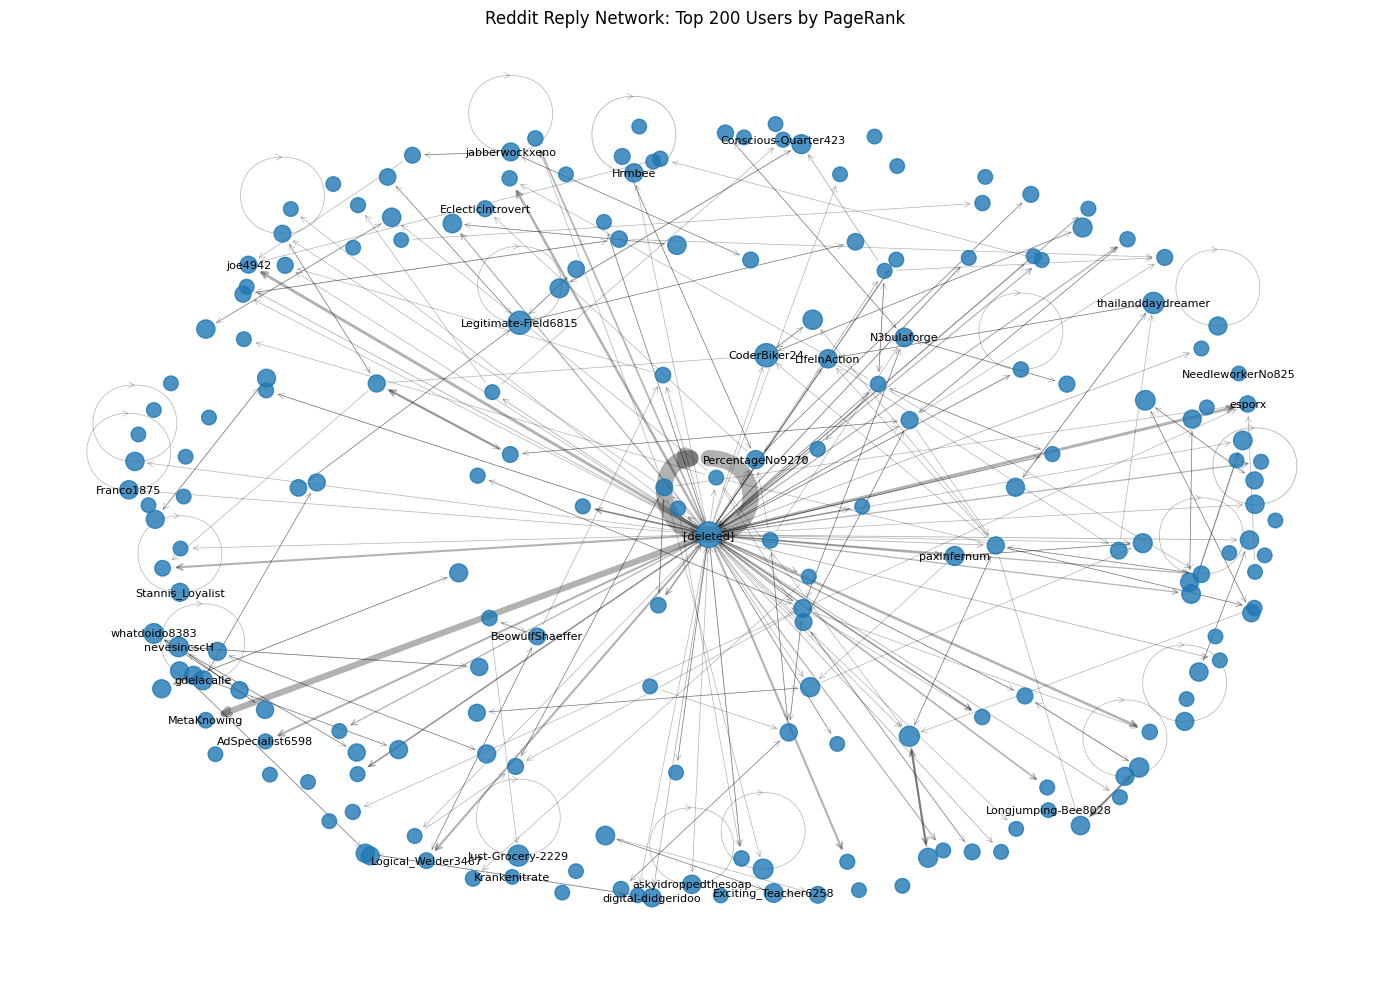

Saved figure to: ..\figures\reddit_reply_network_top200.png


In [91]:
# Plot only top 200 users by PageRank for readable network visualisation

top_users = centrality_df.head(200)["user"].tolist()
G_plot = G.subgraph(top_users).copy()

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G_plot, seed=42, k=0.5)

plot_pagerank = nx.pagerank(G_plot, weight="weight")

node_sizes = [
    100 + (plot_pagerank.get(node, 0) * 8000)
    for node in G_plot.nodes()
]

edge_widths = [
    max(0.5, G_plot[u][v].get("weight", 1) * 0.3)
    for u, v in G_plot.edges()
]

nx.draw_networkx_nodes(
    G_plot,
    pos,
    node_size=node_sizes,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_plot,
    pos,
    width=edge_widths,
    arrows=True,
    arrowstyle="->",
    arrowsize=10,
    alpha=0.3
)

# Label only top 30 users to keep graph readable
top_label_users = set(centrality_df.head(30)["user"])
labels = {node: node for node in G_plot.nodes() if node in top_label_users}

nx.draw_networkx_labels(
    G_plot,
    pos,
    labels=labels,
    font_size=8
)

plt.title("Reddit Reply Network: Top 200 Users by PageRank")
plt.axis("off")
plt.tight_layout()

network_fig_path = FIGURES_DIR / "reddit_reply_network_top200.png"
plt.savefig(network_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", network_fig_path)

## Community Detection

Louvain community detection is applied to the undirected version of the reply network. This helps identify groups of users who interact more strongly with each other than with the rest of the network. In the final project, these communities may represent different discussion groups, such as users focused on entry-level job anxiety, reskilling advice, or broader AI adoption debates.

In [92]:
# Louvain community detection

if G_undirected.number_of_edges() > 0:
    partition = community_louvain.best_partition(G_undirected, weight="weight", random_state=42)
else:
    partition = {node: 0 for node in G_undirected.nodes()}

community_df = pd.DataFrame({
    "user": list(partition.keys()),
    "community": list(partition.values())
}).sort_values(by="community")

community_df

,user,community
36,Own-Necessary4974,0
46,staticjak,0
47,N7Valor,0
48,n1g3r6356,0
49,Ill_Occasion_3240,0
...,...,...
8471,manojbakshikumar,102
8468,geebee123456789,102
8511,darth_vadrrr,103
8513,JuniorFrosting2331,104


In [93]:
# Merge community labels with centrality table
centrality_community_df = centrality_df.merge(community_df, on="user", how="left")

centrality_community_df = centrality_community_df.sort_values(
    by=["community", "pagerank"],
    ascending=[True, False]
)

centrality_community_df

,user,in_degree,out_degree,weighted_in_degree,weighted_out_degree,pagerank,approx_betweenness,community
38,compuwiza1,13,1,13,1,0.002034,0.003195,0
147,throwaway09234023322,32,4,34,5,0.000908,0.005510,0
222,MD90__,15,29,23,34,0.000643,0.028270,0
335,kamilc86,27,0,27,0,0.000452,0.004814,0
346,FantasticEffect10,22,0,24,0,0.000439,0.001062,0
...,...,...,...,...,...,...,...,...
2578,Green_Water8532,1,1,1,1,0.000063,0.000000,102
2579,manojbakshikumar,1,1,1,1,0.000063,0.000000,102
11485,darth_vadrrr,0,0,0,0,0.000015,0.000000,103
5851,BabyJuniorLover,1,0,1,0,0.000027,0.000000,104


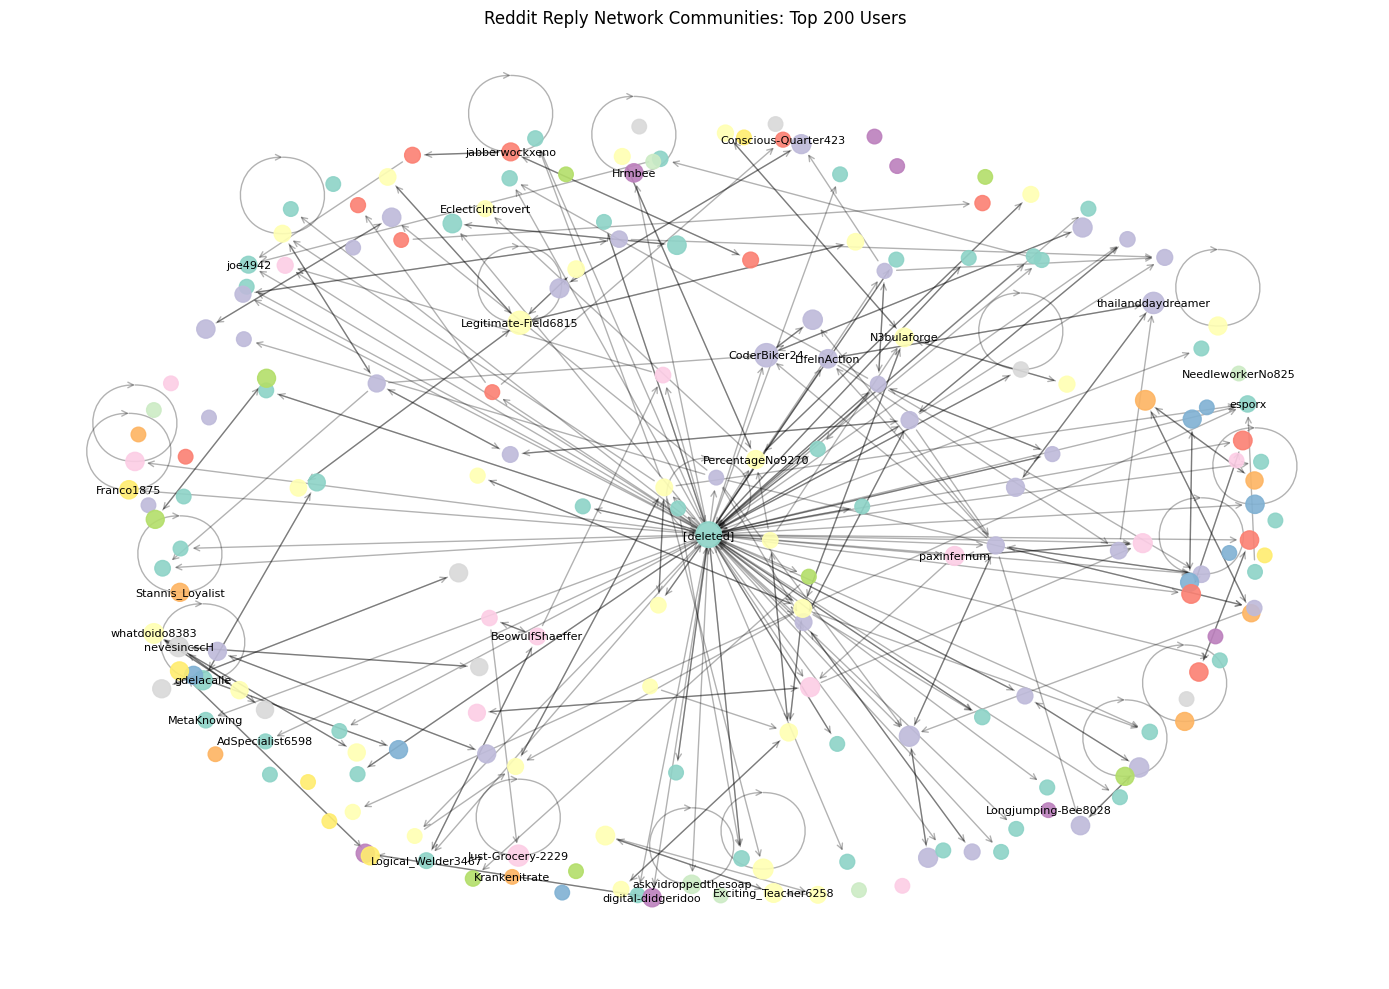

Saved figure to: ..\figures\reddit_reply_network_communities_top200.png


In [95]:
# Louvain community detection on top 200 user network for visualisation

top_users = centrality_df.head(200)["user"].tolist()
G_plot = G.subgraph(top_users).copy()
G_plot_undirected = G_plot.to_undirected()

plot_pagerank = nx.pagerank(G_plot, weight="weight")

if G_plot_undirected.number_of_edges() > 0:
    partition_plot = community_louvain.best_partition(
        G_plot_undirected,
        weight="weight",
        random_state=42
    )
else:
    partition_plot = {node: 0 for node in G_plot_undirected.nodes()}

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G_plot, seed=42, k=0.5)

communities = [partition_plot.get(node, 0) for node in G_plot.nodes()]
node_sizes = [
    100 + (plot_pagerank.get(node, 0) * 8000)
    for node in G_plot.nodes()
]

nx.draw_networkx_nodes(
    G_plot,
    pos,
    node_size=node_sizes,
    node_color=communities,
    cmap=plt.cm.Set3,
    alpha=0.9
)

nx.draw_networkx_edges(
    G_plot,
    pos,
    arrows=True,
    arrowstyle="->",
    arrowsize=10,
    alpha=0.3
)

top_label_users = set(centrality_df.head(30)["user"])
labels = {node: node for node in G_plot.nodes() if node in top_label_users}

nx.draw_networkx_labels(
    G_plot,
    pos,
    labels=labels,
    font_size=8
)

plt.title("Reddit Reply Network Communities: Top 200 Users")
plt.axis("off")
plt.tight_layout()

community_network_fig_path = FIGURES_DIR / "reddit_reply_network_communities_top200.png"
plt.savefig(community_network_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", community_network_fig_path)

### Initial Network Interpretation

The reply network shows how Reddit users interact in AI job replacement discussions. Users with high in-degree receive more replies and may be interpreted as users who attract attention. Users with high out-degree are active responders. PageRank highlights users who are important within the reply structure, while betweenness centrality identifies users who may connect otherwise separate discussion groups. Community detection groups users based on interaction patterns, which helps summarise the structure of the discussion network.

In the final project, these network results will be interpreted together with sentiment and topic modelling. For example, influential users can be examined to determine whether they mainly contribute to anxious discussion, reskilling advice, or neutral explanations about AI adoption.

## Export Analysed Dataset

The analysed dataset is exported so that the final report and repository contain a clear record of the processed data, sentiment results, topic labels, and network-related fields.

In [101]:
# Prepare final analysed dataset safely without duplicate merge problem

df_final = df.copy()

# Add topic results directly by index, not by comment_id
df_final["dominant_topic"] = pd.NA
df_final["topic_label"] = pd.Series([pd.NA] * len(df_final), dtype="object")

# df_non_empty has the same original index positions from df
df_final.loc[df_non_empty.index, "dominant_topic"] = df_non_empty["dominant_topic"].values
df_final.loc[df_non_empty.index, "topic_label"] = df_non_empty["topic_label"].astype("object").values

# Select useful output columns
output_columns = [
    "post_id",
    "comment_id",
    "subreddit",
    "created_utc",
    "author",
    "parent_author",
    "title",
    "text",
    "clean_text",
    "score",
    "num_comments",
    "keyword",
    "compound",
    "sentiment",
    "dominant_topic",
    "topic_label",
    "parent_id"
]

df_final = df_final[output_columns]

# Save final analysed real dataset
final_real_dataset_path = DATA_DIR / "analysed_reddit_ai_jobs_public.csv"
df_final.to_csv(final_real_dataset_path, index=False)

print("Final analysed dataset saved to:", final_real_dataset_path)
print("Shape:", df_final.shape)

df_final.head()

Final analysed dataset saved to: ..\data\analysed_reddit_ai_jobs_public.csv
Shape: (23525, 17)


,post_id,comment_id,subreddit,created_utc,author,parent_author,title,text,clean_text,score,num_comments,keyword,compound,sentiment,dominant_topic,topic_label,parent_id
0,1t6f33z,NaN,cscareerquestions,1.778170e+09,throwaway09234023322,NaN,AI isn't going to take your job and here's why,AI isn't going to take your job and here's why...,going take software engineer going used take e...,96,158,AI jobs,-0.9800,Negative,2,Reskilling and future work adaptation,NaN
1,1t6f33z,okh0tv1,cscareerquestions,1.778171e+09,MD90__,throwaway09234023322,AI isn't going to take your job and here's why,Well I mean cheaper labor can use AI too so a ...,well mean cheaper labor use global market tech...,159,158,AI jobs,0.5106,Positive,2,Reskilling and future work adaptation,t3_1t6f33z
2,1t6f33z,okh1luf,cscareerquestions,1.778171e+09,throwaway09234023322,MD90__,AI isn't going to take your job and here's why,"Tbh, while what you are saying makes logical s...",tbh saying make logical sense personally witne...,28,158,AI jobs,-0.3182,Negative,1,Career anxiety and entry-level concerns,t1_okh0tv1
3,1t6f33z,okh2hl1,cscareerquestions,1.778171e+09,MD90__,throwaway09234023322,AI isn't going to take your job and here's why,What about the folks coming out of college sin...,folk coming college since entry level dead chance,7,158,AI jobs,-0.5661,Negative,2,Reskilling and future work adaptation,t1_okh1luf
4,1t6f33z,okh33et,cscareerquestions,1.778171e+09,throwaway09234023322,MD90__,AI isn't going to take your job and here's why,"I think so, but I think it will take a bit of ...",take bit time realize silver bullet magically ...,10,158,AI jobs,0.0000,Neutral,1,Career anxiety and entry-level concerns,t1_okh2hl1


In [97]:
# Save final real-data outputs with clear filenames

final_real_dataset_path = DATA_DIR / "analysed_reddit_ai_jobs_public.csv"
df_final.to_csv(final_real_dataset_path, index=False)

final_centrality_path = DATA_DIR / "network_centrality_reddit_ai_jobs_public.csv"
centrality_df.to_csv(final_centrality_path, index=False)

print("Saved analysed real dataset to:", final_real_dataset_path)
print("Saved real network centrality table to:", final_centrality_path)
print("Analysed dataset shape:", df_final.shape)
print("Centrality table shape:", centrality_df.shape)

Saved analysed real dataset to: ..\data\analysed_reddit_ai_jobs_public.csv
Saved real network centrality table to: ..\data\network_centrality_reddit_ai_jobs_public.csv
Analysed dataset shape: (140831, 17)
Centrality table shape: (14759, 7)


In [98]:
print("Dataset shape:", df.shape)
print("\nSubreddit counts:")
print(df["subreddit"].value_counts())

print("\nKeyword counts:")
print(df["keyword"].value_counts().head(20))

print("\nNumber of unique authors:", df["author"].nunique())
print("Number of posts:", df["post_id"].nunique())
print("Number of comments/records:", len(df))

Dataset shape: (23525, 17)

Subreddit counts:
subreddit
technology           6919
cscareerquestions    6457
jobs                 4842
careerguidance       2859
learnprogramming     2448
Name: count, dtype: int64

Keyword counts:
keyword
AI jobs                      4686
software engineering jobs    3044
automation                   3000
AI layoffs                   2892
job replacement              2664
entry level AI               1984
AI replacing programmers     1963
ChatGPT jobs                 1893
career anxiety                973
reskilling                    426
Name: count, dtype: int64

Number of unique authors: 14759
Number of posts: 343
Number of comments/records: 23525


In [102]:
print("Sentiment counts:")
print(df_final["sentiment"].value_counts())

print("\nSentiment percentages:")
print((df_final["sentiment"].value_counts(normalize=True) * 100).round(2))

print("\nTopic counts:")
print(df_final["topic_label"].value_counts())

print("\nDataset shape:")
print(df_final.shape)

Sentiment counts:
sentiment
Positive    11741
Negative     7144
Neutral      4640
Name: count, dtype: int64

Sentiment percentages:
sentiment
Positive    49.91
Negative    30.37
Neutral     19.72
Name: proportion, dtype: float64

Topic counts:
topic_label
Reskilling and future work adaptation        9809
AI adoption, automation, and productivity    7635
Career anxiety and entry-level concerns      5936
Name: count, dtype: int64

Dataset shape:
(23525, 17)


In [ ]:
sample_for_repo = df_final.sample(
    n=min(3000, len(df_final)),
    random_state=42
)

sample_repo_path = DATA_DIR / "reddit_ai_jobs_public_sample.csv"
sample_for_repo.to_csv(sample_repo_path, index=False)

print("Saved sample dataset for repository:", sample_repo_path)
print("Shape:", sample_for_repo.shape)